# Transfer Learning
Gender Classification with Celebrity Faces

# Introduction

## Information About the Project

### Objective
The objective of this project is to use transfer learning to build a gender classification model. Transfer learning leverages knowledge from models that were pretrained on millions of images, which dramatically reduces training time while improving overall performance.

### Scope
The scope of the project emphasizes critical production skills, specifically model checkpointing, resuming interrupted training, and fine-tuning strategies. The project covers:  

* Loading and modifying pretrained models from torchvision.  

* Implementing feature extraction (using frozen layers) versus fine-tuning (using trainable layers).

* Saving and loading complete training checkpoints (including both model and optimizer states) for seamless resumption.  

* Comparing different transfer learning strategies and understanding progressive layer unfreezing.

## Description of the Dataset
* Source: The dataset consists of celebrity face images, which act as a subset of the larger CelebA dataset.

* Size: The dataset is perfectly balanced, featuring approximately 50% female and 50% male images. The original images are 178x218 pixels, but they must be resized to 224x224 pixels to meet the requirements for the ResNet model. Depending on the dataset scale used, it contains either 2,000 images (small dataset) or 10,000 images (medium dataset).

* Type: The dataset consists of unstructured image data saved as .jpg files.

## Description of the Columns
* Target Variable: The target variable is a binary classification for gender. The labels are derived from the filenames, where files named female.X.jpg map to label 0, and files named man.X.jpg map to label 1.

* Feature Variables: The input features are RGB image tensors loaded via PIL. The images are passed through a transform pipeline where they are converted to tensors and normalized. It is required to use specific ImageNet normalization statistics where the mean is [0.485, 0.456, 0.406] and the standard deviation is [0.229, 0.224, 0.225].

# Task 1: Setup and Data Exploration

## Step 1.1: Import Libraries and Set Seeds

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn import metrics
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
import copy

import warnings
warnings.filterwarnings("ignore")

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
seed = 42
set_seed(seed)

# Configure device for GPU/CPU use
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Step 1.2: Explore Dataset

--- Dataset Statistics ---
Total images: 3801
Female images: 1909 (50.22%)
Male images:   1892 (49.78%)


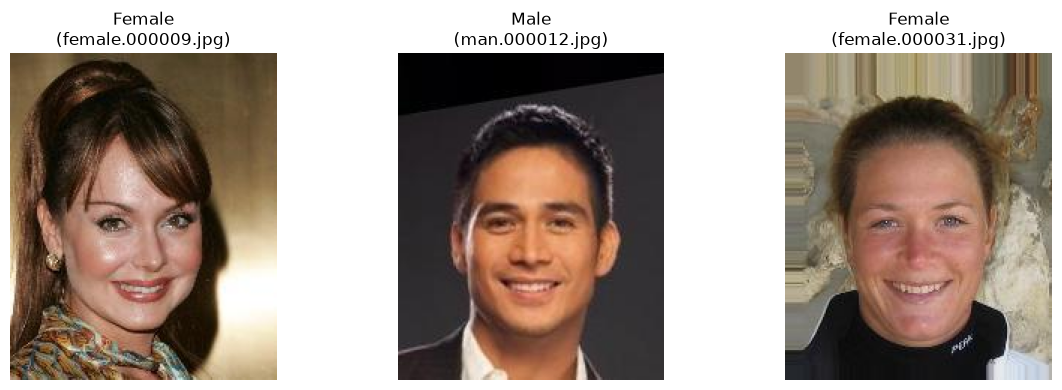

In [ ]:
data_dir = '../../data/celeb_small'

# List all .jpg files
all_images = [f for f in os.listdir(data_dir) if f.endswith('.jpg')]

# Count female vs male images
female_images = [f for f in all_images if f.startswith('female')]
male_images = [f for f in all_images if f.startswith('man')]

num_female = len(female_images)
num_male = len(male_images)
total_images = len(all_images)

# Print dataset statistics 
print("--- Dataset Statistics ---")
print(f"Total images: {total_images}")

if total_images > 0:
    female_pct = (num_female / total_images) * 100
    male_pct = (num_male / total_images) * 100
    print(f"Female images: {num_female} ({female_pct:.2f}%)")
    print(f"Male images:   {num_male} ({male_pct:.2f}%)")
else:
    print("Warning: No .jpg files found. Check your 'data_dir' path.")

# Sample images with labels
if total_images >= 3:
    # 2 females and 1 male
    sample_files = [female_images[0], male_images[0], female_images[1]]
    
    # Plot with 1 row and 3 columns
    plt.figure(figsize=(12, 4))
    
    for i, file_name in enumerate(sample_files):
        img_path = os.path.join(data_dir, file_name)
        img = Image.open(img_path)
        
        # Determine the label based on the filename
        if file_name.startswith('female'):
            label_text = "Female"
        else:
            label_text = "Male"
            
        plt.subplot(1, 3, i + 1)
        plt.imshow(img)
        plt.title(f"{label_text}\n({file_name})")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Task 2: Create Custom Dataset

## Step 2.1: Build CelebGenderDataset Class
PyTorch Dataset class loads data as needed and applies transformations to each item loaded.

In [6]:
class CelebGenderDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        """
        Constructor for the CelebGenderDataset.
        """
        # Store directory and transforms
        self.img_dir = img_dir
        self.transform = transform
        
        # List all .jpg files in the provided directory
        self.image_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
        
        # Create label map as requested
        self.label_map = {'female': 0, 'man': 1}

    def __len__(self):
        """
        Returns the total number of images in the dataset.
        """
        return len(self.image_files)

    def __getitem__(self, idx):
        """
        Retrieves the image and its corresponding label at the specified index.
        """
        # Get filename at index
        filename = self.image_files[idx]
        
        # Get category
        category = filename.split('.')[0]
        
        # Map the category to its numerical label
        label = self.label_map[category]
        
        # Load image with PIL, convert to RGB to ensure 3 channels
        img_path = os.path.join(self.img_dir, filename)
        image = Image.open(img_path).convert("RGB")
        
        # Apply transforms if provided
        if self.transform:
            image = self.transform(image)
            
        # Return (image, label) tuple
        return image, label

# Task 3: Define Transforms and Create DataLoaders

## Step 3.1: Create Image Transforms
PyTorch transforms serve two functions, data preprocessing (making raw data compatible with the model, ResNet18 here) and data augmentation (improving model accuracy and preventing overfitting)

In [7]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
            brightness=0.2, 
            contrast=0.2, 
            saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
            mean=imagenet_mean,
            std=imagenet_std
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

## Step 3.2: Split Dataset
In comparison to train_test_split, random_split is used on PyTorch Dataset objects.

In [8]:
# Full dataset without any transformations
full_dataset = CelebGenderDataset(img_dir=data_dir, transform=None)

# Split sizes
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

print(f"Total dataset size: {total_size}")
print(f"Training size: {train_size} (70%)")
print(f"Validation size: {val_size} (15%)")
print(f"Test size: {test_size} (15%)")

# Create splits
generator = torch.Generator().manual_seed(seed)
train_subset, val_subset, test_subset = random_split(
    full_dataset, 
    [train_size, val_size, test_size], 
    generator=generator
)

# Apply training transforms
train_subset.dataset = copy.copy(full_dataset)
train_subset.dataset.transform = train_transforms

# Apply test transforms (no augmentation)
val_subset.dataset = copy.copy(full_dataset)
val_subset.dataset.transform = test_transforms

test_subset.dataset = copy.copy(full_dataset)
test_subset.dataset.transform = test_transforms

Total dataset size: 3801
Training size: 2660 (70%)
Validation size: 570 (15%)
Test size: 571 (15%)


## Step 3.3: Create DataLoaders
PyTorch Dataloader is designed to simplify loading and iterating over datasets while training deep learning models.

In [ ]:
batch_size = 32
num_workers = 0
pin_memory = True if torch.cuda.is_available() else False

train_loader = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory
)

val_loader = DataLoader(
    val_subset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_subset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

print("--- DataLoader Batch Verification ---")
print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")

--- DataLoader Batch Verification ---
Training batches:   42
Validation batches: 9
Test batches:       9


# Task 4: Load and Modify Pretrained ResNet18

## Step 4.1: Load Pretrained Model

In [12]:
# Load ResNet18 pretrained on ImageNet
model = models.resnet18(pretrained=True)

# Examine model structure
print("--- ResNet18 Architecture ---")
print(model)

# Final fully connected (fc) layer
print("\n--- Original Final FC Layer ---")
print(model.fc)

--- ResNet18 Architecture ---
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True

ResNet18 Final FC Layer
* Input features (in_features=512): output dimensions
* Output features (out_features=1000): classification categories

## Step 4.2: Modify Final Layer

In [13]:
# Get number of original fc input features
num_fc_features = model.fc.in_features

# Replace model.fc with a single output neuron for binary classification
model.fc = nn.Linear(num_fc_features, 1)

# Move model to device
model = model.to(device)

# Verify modified fc layer
print("--- Modified Final FC Layer ---")
print(model.fc)

--- Modified Final FC Layer ---
Linear(in_features=512, out_features=1, bias=True)


## Step 4.3: Freeze Feature Extractor

In [14]:
# Loop through named parameters and freeze feature extractor layers
for name, param in model.named_parameters():
    if 'fc' not in name:
        param.requires_grad = False
    else:
        param.requires_grad = True

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params
pct_trainable = (trainable_params / total_params) * 100

# Model parameter statistics
print("--- Parameter Statistics ---")
print(f"Total Parameters:     {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Frozen Parameters:    {frozen_params:,}")
print(f"Percentage Trainable: {pct_trainable:.2f}%")

--- Parameter Statistics ---
Total Parameters:     11,177,025
Trainable Parameters: 513
Frozen Parameters:    11,176,512
Percentage Trainable: 0.00%


# Task 5: Setup Training Components

## Step 5.1: Define Loss and Optimizer

In [15]:
# Loss function
criterion = nn.BCEWithLogitsLoss()

# Optimizer
# Filter for parameters where requires_grad=True to ensure Adam only tracks active layers
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

# Configuration details
print("--- Training Configuration ---")
print(f"Loss Function: {criterion.__class__.__name__}")
print(f"Optimizer:     {optimizer.__class__.__name__}")
print(f"Learning Rate: {optimizer.param_groups[0]['lr']}")
print(f"Target Device: {device}")

--- Training Configuration ---
Loss Function: BCEWithLogitsLoss
Optimizer:     Adam
Learning Rate: 0.001
Target Device: cuda


## Step 5.2: Implement Training and Validation Functions

In [16]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """
    Trains the model for one epoch.
    """
    # Train mode
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Loop through batches
    for images, labels in dataloader:
        # Move data to device
        images = images.to(device)
        labels = labels.to(device).float()

        # Zero parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        # Reshape output from [batch_size, 1] to [batch_size]
        outputs = model(images).squeeze(-1)
        loss = criterion(outputs, labels)
        
        # Backpropagate and update weights
        loss.backward()
        optimizer.step()

        # Track loss and accuracy
        # Convert logits to probabilities using sigmoid, then threshold at 0.5
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()
        
        running_loss += loss.item() * images.size(0)
        correct_predictions += (preds == labels).sum().item()
        total_samples += images.size(0)

    # Return average loss and accuracy for the epoch
    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples
    
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device):
    """
    Evaluates the model on validation or test data without backpropagation.
    """
    # Evaluation mode
    model.eval()
    
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    # No gradient computation
    with torch.no_grad():
        # Loop through batches
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device).float()
            
            # Forward pass
            outputs = model(images).squeeze(-1)
            loss = criterion(outputs, labels)
            
            # Track loss and accuracy (no backprop)
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()
            
            running_loss += loss.item() * images.size(0)
            correct_predictions += (preds == labels).sum().item()
            total_samples += images.size(0)
            
    # Return average loss and accuracy
    val_loss = running_loss / total_samples
    val_acc = correct_predictions / total_samples
    
    return val_loss, val_acc

# Task 6: Implement Checkpoint Functions

## Step 6.1: Create save checkpoint Function

In [17]:
def save_checkpoint(epoch, model, optimizer, train_loss, val_loss, train_acc, val_acc, history, filepath):
    """
    Saves the complete training state to a file checkpoint.
    """
    # Create checkpoint dictionary 
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'history': history
    }
    
    # Save the dictionary to disk
    torch.save(checkpoint, filepath)
    print(f"Checkpoint saved to '{filepath}' (Epoch {epoch})")

## Step 6.2: Create load checkpoint Function

In [18]:
def load_checkpoint(filepath, model, optimizer=None, device='cpu'):
    """
    Loads a complete training state from a checkpoint file.
    """
    # Load checkpoint 
    checkpoint = torch.load(filepath, map_location=device)
    
    # Restore model state dict
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Restore optimizer state dict (if optimizer is provided)
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        
    # Get epoch and history
    epoch = checkpoint['epoch']
    history = checkpoint['history']
    
    # loaded information
    print(f"--- Checkpoint Loaded ---")
    print(f"File: {filepath}")
    print(f"Resumed from Epoch: {epoch}")
    print(f"Saved Training Loss: {checkpoint.get('train_loss', 'N/A'):.4f}")
    print(f"Saved Validation Acc: {checkpoint.get('val_acc', 'N/A'):.4f}")
    
    if optimizer is not None:
        print("Optimizer state successfully restored.")
    else:
        print("Model state restored (Optimizer state skipped).")
        
    # Return epoch and history
    return epoch, history

# Task 7: Phase 1 - Initial Training (Frozen Features)

## Step 7.1: Train with Frozen Features

In [ ]:
# History dictionary
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'epochs': []
}

# Variable to track the best validation accuracy seen so far
best_val_acc = 0.0
num_epochs_phase1 = 5

print("--- Starting Phase 1 Training (Frozen Features) ---")
start_time = time.time()

# Loop for each epoch (1-5)
for epoch in range(1, num_epochs_phase1 + 1):
    epoch_start = time.time()
    
    # Call train_one_epoch
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    
    # Call validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # Append metrics to history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['epochs'].append(epoch)
    
    # Print epoch results
    epoch_time = time.time() - epoch_start
    print(f"\nEpoch {epoch:02d}/{num_epochs_phase1} | Time: {epoch_time:.0f}s")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    
    # Save standard checkpoint with filename: checkpoint_epoch_XX.pth
    epoch_filename = f"celeb_small_checkpoints/checkpoint_epoch_{epoch:02d}.pth"
    save_checkpoint(
        epoch=epoch,
        model=model,
        optimizer=optimizer,
        train_loss=train_loss,
        val_loss=val_loss,
        train_acc=train_acc,
        val_acc=val_acc,
        history=history,
        filepath=epoch_filename
    )
    
    # If validation accuracy improves: save as checkpoint_best_phase1.pth
    if val_acc > best_val_acc:
        print(f"  --> Val Acc improved from {best_val_acc:.4f} to {val_acc:.4f}. Saving best model...")
        best_val_acc = val_acc
        save_checkpoint(
            epoch=epoch,
            model=model,
            optimizer=optimizer,
            train_loss=train_loss,
            val_loss=val_loss,
            train_acc=train_acc,
            val_acc=val_acc,
            history=history,
            filepath="celeb_small_checkpoints/checkpoint_best_phase1.pth"
        )
        
total_time = time.time() - start_time
print(f"\n--- Phase 1 Training Complete in {total_time/60:.2f} minutes ---")

--- Starting Phase 1 Training (Frozen Features) ---

Epoch 01/5 | Time: 27s
  Train Loss: 0.5262 | Train Acc: 0.7647
  Val Loss:   0.3961 | Val Acc:   0.8368
Checkpoint saved to 'checkpoint_epoch_01.pth' (Epoch 1)
  --> Val Acc improved from 0.0000 to 0.8368. Saving best model...
Checkpoint saved to 'checkpoint_best_phase1.pth' (Epoch 1)

Epoch 02/5 | Time: 10s
  Train Loss: 0.3648 | Train Acc: 0.8677
  Val Loss:   0.3300 | Val Acc:   0.8614
Checkpoint saved to 'checkpoint_epoch_02.pth' (Epoch 2)
  --> Val Acc improved from 0.8368 to 0.8614. Saving best model...
Checkpoint saved to 'checkpoint_best_phase1.pth' (Epoch 2)

Epoch 03/5 | Time: 9s
  Train Loss: 0.3213 | Train Acc: 0.8699
  Val Loss:   0.2761 | Val Acc:   0.9035
Checkpoint saved to 'checkpoint_epoch_03.pth' (Epoch 3)
  --> Val Acc improved from 0.8614 to 0.9035. Saving best model...
Checkpoint saved to 'checkpoint_best_phase1.pth' (Epoch 3)

Epoch 04/5 | Time: 9s
  Train Loss: 0.3014 | Train Acc: 0.8842
  Val Loss:   0.2715 

# Task 8: Phase 2 - Load Checkpoint and Continue Training

## Step 8.1: Load Best Checkpoint

In [ ]:
best_epoch, history = load_checkpoint(
    filepath="celeb_small_checkpoints/checkpoint_best_phase1.pth",
    model=model,
    optimizer=optimizer,
    device=device
)

--- Checkpoint Loaded ---
File: checkpoint_best_phase1.pth
Resumed from Epoch: 5
Saved Training Loss: 0.2813
Saved Validation Acc: 0.9158
Optimizer state successfully restored.


## Step 8.2: Verify Loaded State
From loaded checkpoint: "Saved Validation Acc: 0.9158"

From training: "Val Acc improved from 0.9035 to 0.9158"

## Step 8.3: Continue Training for 5 More Epochs

In [ ]:
# Calculate starting (from load_checkpoint()) and total epoch for phase 2 of training
start_epoch = best_epoch + 1
total_epochs_phase2 = 10

# Initialize best validation accuracy from history dictionary
best_val_acc = max(history['val_acc']) if history['val_acc'] else 0.0

print(f"--- Starting Phase 2 Training (Continued Training: Epochs {start_epoch} to {total_epochs_phase2}) ---")
print(f"Resuming from Epoch {start_epoch} | Current Best Val Acc: {best_val_acc:.4f}")

start_time = time.time()

# Loop for epochs 6 through 10
for epoch in range(start_epoch, total_epochs_phase2 + 1):
    epoch_start = time.time()
    
    # Train and validate for one epoch
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # Append metrics to existing history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['epochs'].append(epoch)
    
    # Print epoch results
    epoch_time = time.time() - epoch_start
    print(f"\nEpoch {epoch:02d}/{total_epochs_phase2} | Time: {epoch_time:.0f}s")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    
    # Save standard epoch checkpoint
    epoch_filename = f"celeb_small_checkpoints/checkpoint_epoch_{epoch:02d}.pth"
    save_checkpoint(
        epoch=epoch,
        model=model,
        optimizer=optimizer,
        train_loss=train_loss,
        val_loss=val_loss,
        train_acc=train_acc,
        val_acc=val_acc,
        history=history,
        filepath=epoch_filename
    )
    
    # Update best model if validation accuracy improves
    if val_acc > best_val_acc:
        print(f"  --> Val Acc improved from {best_val_acc:.4f} to {val_acc:.4f}. Saving best model for Phase 2...")
        best_val_acc = val_acc
        save_checkpoint(
            epoch=epoch,
            model=model,
            optimizer=optimizer,
            train_loss=train_loss,
            val_loss=val_loss,
            train_acc=train_acc,
            val_acc=val_acc,
            history=history,
            filepath="celeb_small_checkpoints/checkpoint_best_phase2.pth"
        )

total_time = time.time() - start_time
print(f"\n--- Phase 2 Training Complete in {total_time/60:.2f} minutes ---")

--- Starting Phase 2 Training (Continued Training: Epochs 6 to 10) ---
Resuming from Epoch 6 | Current Best Val Acc: 0.9158

Epoch 06/10 | Time: 9s
  Train Loss: 0.2765 | Train Acc: 0.8865
  Val Loss:   0.2375 | Val Acc:   0.9140
Checkpoint saved to 'checkpoint_epoch_06.pth' (Epoch 6)

Epoch 07/10 | Time: 9s
  Train Loss: 0.2683 | Train Acc: 0.8902
  Val Loss:   0.2424 | Val Acc:   0.9053
Checkpoint saved to 'checkpoint_epoch_07.pth' (Epoch 7)

Epoch 08/10 | Time: 9s
  Train Loss: 0.2691 | Train Acc: 0.8898
  Val Loss:   0.2301 | Val Acc:   0.9158
Checkpoint saved to 'checkpoint_epoch_08.pth' (Epoch 8)

Epoch 09/10 | Time: 9s
  Train Loss: 0.2613 | Train Acc: 0.8914
  Val Loss:   0.2312 | Val Acc:   0.9105
Checkpoint saved to 'checkpoint_epoch_09.pth' (Epoch 9)

Epoch 10/10 | Time: 9s
  Train Loss: 0.2562 | Train Acc: 0.8955
  Val Loss:   0.2457 | Val Acc:   0.9018
Checkpoint saved to 'checkpoint_epoch_10.pth' (Epoch 10)

--- Phase 2 Training Complete in 0.73 minutes ---


# Task 9: Phase 3 - Fine-Tuning (Unfreeze Layers)

## Step 9.1: Unfreeze Last Residual Block

# 

## 